### Import Libraries

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings("ignore", message=".*observed=False.*")

#### Load data (d_icd_diagnoses.csv and diagnoses_icd from the hosp folder)

In [23]:
df = pd.read_csv("d_icd_diagnoses.csv")
df.head()

,icd_code,icd_version,long_title
0,0010,9,Cholera due to vibrio cholerae
1,0011,9,Cholera due to vibrio cholerae el tor
2,0019,9,"Cholera, unspecified"
3,0020,9,Typhoid fever
4,0021,9,Paratyphoid fever A


In [24]:
df2 = pd.read_csv("diagnoses_icd.csv")
df2.head()

,subject_id,hadm_id,seq_num,icd_code,icd_version
0,10000032,22595853,1,5723,9
1,10000032,22595853,2,78959,9
2,10000032,22595853,3,5715,9
3,10000032,22595853,4,07070,9
4,10000032,22595853,5,496,9


#### diagnoses_icd has the details I need, so proceed with that and name it df2

In [25]:
len(df2)

6364488

#### Use ICD 9 and 10 codes to filter stroke cases. First including TIAs and later removing them. The resulting data is called df_stroke

In [26]:
df2["icd_code_str"] = df2["icd_code"].astype(str)
# For ICD-9
stroke_icd9 = {
    "430", "431", "432", "433", "434", "436", "437", "438",
    "V1254"
}

# For ICD-10
stroke_icd10_prefixes = [
    "I60", "I61", "I62", "I63", "I64", "I65", "I66", "I67", "I68", "I69"
]

In [27]:
def is_stroke_icd9(code_str: str) -> bool:
    """
    Return True if code_str corresponds to ICD-9 stroke codes.
    We match if the code_str starts with one of the 9-stroke codes (for 3-digit codes)
    or exactly equals a history code.
    """
    if code_str in stroke_icd9:
        return True
    for p in ["430", "431", "432", "433", "434", "436", "437", "438"]:
        if code_str.startswith(p):
            return True
    if code_str == "V1254":
        return True
    return False

In [28]:
def is_stroke_icd10(code_str: str) -> bool:
    """
    Return True if code_str corresponds to ICD-10 stroke codes.
    We match if it starts with a known stroke prefix.
    """
    for pref in stroke_icd10_prefixes:
        if code_str.startswith(pref):
            return True
    return False

In [29]:
mask = (
    ((df2['icd_version'] == 9) & (df2['icd_code_str'].apply(is_stroke_icd9))) |
    ((df2['icd_version'] == 10) & (df2['icd_code_str'].apply(is_stroke_icd10)))
)
df_stroke = df2[mask].copy()

In [30]:
df_stroke = df_stroke.drop(columns=['icd_code_str'])
print("Filtered stroke-related rows:", df_stroke.shape[0])
df_stroke.head()

Filtered stroke-related rows: 60321


,subject_id,hadm_id,seq_num,icd_code,icd_version
350,10000980,24947999,11,V1254,9
379,10000980,25242409,19,V1254,9
428,10000980,26913865,12,V1254,9
438,10000980,29654838,7,V1254,9
818,10001877,25679292,2,43411,9


In [31]:
df_stroke.to_csv("df_stroke.csv")

#### Remove duplicate entries and keep the last (assuming the most recent entry will record a death if there was one)

In [32]:
df_stroke_unique = df_stroke.drop_duplicates(subset=["subject_id"],  keep="last").copy()
print(f"Number of unique stroke cases: {len(df_stroke_unique)}")

Number of unique stroke cases: 26381


In [33]:
df_stroke_unique.to_csv("df_stroke_unique.csv")

#### Load patients data with biodata, including date of death, name it patient_info

In [34]:
patient_info = pd.read_csv("patients.csv")
patient_info.head()

,subject_id,gender,anchor_age,anchor_year,anchor_year_group,dod
0,10000032,F,52,2180,2014 - 2016,2180-09-09
1,10000048,F,23,2126,2008 - 2010,NaN
2,10000058,F,33,2168,2020 - 2022,NaN
3,10000068,F,19,2160,2008 - 2010,NaN
4,10000084,M,72,2160,2017 - 2019,2161-02-13


In [35]:
patient_info.columns

Index(['subject_id', 'gender', 'anchor_age', 'anchor_year',
       'anchor_year_group', 'dod'],
      dtype='object')

#### Extract stroke patient data in patient_info using subject ids from df_stroke

In [36]:
stroke_subject_ids = df_stroke["subject_id"].tolist()

In [37]:
df_stroke_patients = patient_info[patient_info["subject_id"].isin(stroke_subject_ids)][["subject_id", "gender", "anchor_age", "dod"]].copy()
df_stroke_patients.head()

,subject_id,gender,anchor_age,dod
38,10000980,F,73,2193-08-26
67,10001877,M,89,NaN
77,10002155,F,80,2131-03-10
82,10002221,F,68,NaN
89,10002430,M,86,2130-01-11


#### Create mortality column set to True if there is a date of death and False otherwise

In [38]:
df_stroke_patients["mortality"] = df_stroke_patients["dod"].notna().astype(int)
df_stroke_patients.head()

,subject_id,gender,anchor_age,dod,mortality
38,10000980,F,73,2193-08-26,1
67,10001877,M,89,NaN,0
77,10002155,F,80,2131-03-10,1
82,10002221,F,68,NaN,0
89,10002430,M,86,2130-01-11,1


In [39]:
print("Number of stroke patients in patient info dataset: ", len(df_stroke_patients))

Number of stroke patients in patient info dataset:  26381


#### Load the admissions dataset to get more patient information

In [40]:
admissions_data = pd.read_csv("admissions.csv")
admissions_data.head()

,subject_id,hadm_id,admittime,dischtime,deathtime,admission_type,admit_provider_id,admission_location,discharge_location,insurance,language,marital_status,race,edregtime,edouttime,hospital_expire_flag
0,10000032,22595853,2180-05-06 22:23:00,2180-05-07 17:15:00,NaN,URGENT,P49AFC,TRANSFER FROM HOSPITAL,HOME,Medicaid,English,WIDOWED,WHITE,2180-05-06 19:17:00,2180-05-06 23:30:00,0
1,10000032,22841357,2180-06-26 18:27:00,2180-06-27 18:49:00,NaN,EW EMER.,P784FA,EMERGENCY ROOM,HOME,Medicaid,English,WIDOWED,WHITE,2180-06-26 15:54:00,2180-06-26 21:31:00,0
2,10000032,25742920,2180-08-05 23:44:00,2180-08-07 17:50:00,NaN,EW EMER.,P19UTS,EMERGENCY ROOM,HOSPICE,Medicaid,English,WIDOWED,WHITE,2180-08-05 20:58:00,2180-08-06 01:44:00,0
3,10000032,29079034,2180-07-23 12:35:00,2180-07-25 17:55:00,NaN,EW EMER.,P06OTX,EMERGENCY ROOM,HOME,Medicaid,English,WIDOWED,WHITE,2180-07-23 05:54:00,2180-07-23 14:00:00,0
4,10000068,25022803,2160-03-03 23:16:00,2160-03-04 06:26:00,NaN,EU OBSERVATION,P39NWO,EMERGENCY ROOM,NaN,NaN,English,SINGLE,WHITE,2160-03-03 21:55:00,2160-03-04 06:26:00,0


#### Filter the admissions dataset with subject ids of stroke patients from df_stroke

In [41]:
admissions_stroke_data = admissions_data[admissions_data["subject_id"].isin(stroke_subject_ids)][["subject_id", "admittime", "dischtime", "deathtime", "admission_type", "race"]].copy()
admissions_stroke_data.head()

,subject_id,admittime,dischtime,deathtime,admission_type,race
36,10000980,2193-08-15 01:01:00,2193-08-17 15:07:00,NaN,OBSERVATION ADMIT,BLACK/AFRICAN AMERICAN
37,10000980,2190-11-06 20:57:00,2190-11-08 15:58:00,NaN,EW EMER.,BLACK/AFRICAN AMERICAN
38,10000980,2191-04-03 18:48:00,2191-04-11 16:21:00,NaN,EW EMER.,BLACK/AFRICAN AMERICAN
39,10000980,2191-05-23 15:33:00,2191-05-24 17:14:00,NaN,EW EMER.,BLACK/AFRICAN AMERICAN
40,10000980,2189-06-27 07:38:00,2189-07-03 03:00:00,NaN,EW EMER.,BLACK/AFRICAN AMERICAN


#### Remove duplicates from the admissions dataset, keeping the last entry (also based on the assumption that the last entry contains death information if there is any)

In [42]:
print("Number of stroke patients with data in admissions dataset with duplicates", len(admissions_stroke_data))

Number of stroke patients with data in admissions dataset with duplicates 93413


In [43]:
admissions_stroke_data_unique = admissions_stroke_data.drop_duplicates(subset=["subject_id"], keep="last").copy()

In [44]:
print("Number of stroke patients with data in admissions dataset without duplicates", len(admissions_stroke_data_unique))

Number of stroke patients with data in admissions dataset without duplicates 26381


In [45]:
admissions_stroke_data_unique.head()

,subject_id,admittime,dischtime,deathtime,admission_type,race
42,10000980,2191-07-16 14:21:00,2191-07-19 13:03:00,NaN,EW EMER.,BLACK/AFRICAN AMERICAN
74,10001877,2149-05-21 15:53:00,2149-05-27 13:35:00,NaN,EW EMER.,WHITE
125,10002155,2130-09-23 21:59:00,2130-09-29 18:55:00,NaN,EW EMER.,WHITE
133,10002221,2204-07-17 06:10:00,2204-07-25 14:05:00,NaN,EW EMER.,WHITE
149,10002430,2125-06-23 09:00:00,2125-06-25 11:42:00,NaN,URGENT,WHITE


#### Merge the data from the patient_info data and admissions data on the subject_id column

In [46]:
new_stroke_data = pd.merge(df_stroke_patients, admissions_stroke_data_unique, on="subject_id", how='left')
new_stroke_data.head()

,subject_id,gender,anchor_age,dod,mortality,admittime,dischtime,deathtime,admission_type,race
0,10000980,F,73,2193-08-26,1,2191-07-16 14:21:00,2191-07-19 13:03:00,NaN,EW EMER.,BLACK/AFRICAN AMERICAN
1,10001877,M,89,NaN,0,2149-05-21 15:53:00,2149-05-27 13:35:00,NaN,EW EMER.,WHITE
2,10002155,F,80,2131-03-10,1,2130-09-23 21:59:00,2130-09-29 18:55:00,NaN,EW EMER.,WHITE
3,10002221,F,68,NaN,0,2204-07-17 06:10:00,2204-07-25 14:05:00,NaN,EW EMER.,WHITE
4,10002430,M,86,2130-01-11,1,2125-06-23 09:00:00,2125-06-25 11:42:00,NaN,URGENT,WHITE


#### Trying to determine what date of death value to use, whether that from patient_info or admissions

In [47]:
new_stroke_data["dod"].isnull().sum()

np.int64(17367)

In [48]:
new_stroke_data["deathtime"].isnull().sum()

np.int64(24366)

#### The number of deaths recorded in the patient_info data is more than the number of deaths recorded in the admissions data. This makes sense because the data in patient_info comprises death both inside and outside the hospital

In [49]:
null_mask = new_stroke_data["dod"].isna() & new_stroke_data["deathtime"].notna()
null_dod_with_deathtime = new_stroke_data[null_mask]
print(len(null_dod_with_deathtime))

0


In [50]:
null_mask = new_stroke_data["deathtime"].isna() & new_stroke_data["dod"].notna()
null_deathtime_with_dod = new_stroke_data[null_mask]
print(len(null_deathtime_with_dod))

6999


#### There is no instance where a patient is dead in admissions, but not dead in patient_info, which is good.  
There are 6999 instances where the patient is dead in patient_info, but is not dead in admissions (basically, the patient did not die while admitted in the hospital).  

The question now is, what date of death should be used? There's a tradeoff between data imbalance here and accuracy. If we use the date of death from admssions, we are sure that these patients died while admitted in the hospital for stroke, but we have very imbalanced data.  
Meanwhile, using the dod from patient_info handles some of the class imbalance, but we cannot say for sure that the patients dies of stroke.

In [51]:
without_dod = df_stroke_patients[df_stroke_patients["dod"].isna()]

In [52]:
with_dod = df_stroke_patients[df_stroke_patients["dod"].notna()]

#### Verify that for duplicates in the admissions data, the entry with a deathtime was selected
1) Using the date of death from the patient_info data, split the patient_info data into rows with dead patients and rows with living patients, keeping only the subject ids
2) For rows with living patients, simply merge with the admissions data.
3) For rows with dead patients, go back to the admissions data and filter duplicates, prioritizing rows with a deathtime value (assuming that the last entry will have the deathtime might have been a wrong assumption, the goal is to correct this).  
4) Merge the result of (2) with the admissions data.  
5) Join the data for living and dead patients and merge the result with the rest of the patient_info data to get other details

In [53]:
without_dod_ids = without_dod["subject_id"].tolist()

In [54]:
with_dod_ids = with_dod["subject_id"].tolist()

In [55]:
without_dod_join_admissions = admissions_data[admissions_data["subject_id"].isin(without_dod_ids)][["subject_id", "admittime", "dischtime", "deathtime", "admission_type", "race"]].copy()
print("Number of stroke cases without dod (plus duplicates): ", len(without_dod_join_admissions))

Number of stroke cases without dod (plus duplicates):  51622


In [56]:
without_dod_join_admissions.head()

,subject_id,admittime,dischtime,deathtime,admission_type,race
73,10001877,2150-11-21 23:02:00,2150-11-23 16:46:00,NaN,EU OBSERVATION,WHITE
74,10001877,2149-05-21 15:53:00,2149-05-27 13:35:00,NaN,EW EMER.,WHITE
128,10002221,2203-06-13 00:00:00,2203-06-16 13:28:00,NaN,SURGICAL SAME DAY ADMISSION,WHITE
129,10002221,2204-07-03 22:34:00,2204-07-06 15:00:00,NaN,EW EMER.,WHITE
130,10002221,2200-09-29 17:28:00,2200-10-01 14:58:00,NaN,EW EMER.,WHITE


In [57]:
without_dod_admissions_unique = without_dod_join_admissions.drop_duplicates(subset=["subject_id"], keep="last").copy()
print("Number of stroke cases without dod (without duplicates): ", len(without_dod_admissions_unique))

Number of stroke cases without dod (without duplicates):  17367


In [58]:
with_dod_join_admissions = admissions_data[admissions_data["subject_id"].isin(with_dod_ids)][["subject_id", "admittime", "dischtime", "deathtime", "admission_type", "race"]].copy()
print("Number of stroke cases with dod (plus duplicates): ", len(without_dod_join_admissions))

Number of stroke cases with dod (plus duplicates):  51622


In [59]:
with_dod_join_admissions.head()

,subject_id,admittime,dischtime,deathtime,admission_type,race
36,10000980,2193-08-15 01:01:00,2193-08-17 15:07:00,NaN,OBSERVATION ADMIT,BLACK/AFRICAN AMERICAN
37,10000980,2190-11-06 20:57:00,2190-11-08 15:58:00,NaN,EW EMER.,BLACK/AFRICAN AMERICAN
38,10000980,2191-04-03 18:48:00,2191-04-11 16:21:00,NaN,EW EMER.,BLACK/AFRICAN AMERICAN
39,10000980,2191-05-23 15:33:00,2191-05-24 17:14:00,NaN,EW EMER.,BLACK/AFRICAN AMERICAN
40,10000980,2189-06-27 07:38:00,2189-07-03 03:00:00,NaN,EW EMER.,BLACK/AFRICAN AMERICAN


In [60]:
with_dod_join_admissions["deathtime_flag"] = with_dod_join_admissions["deathtime"].notna()
with_dod_admissions_sorted = with_dod_join_admissions.sort_values(by=["subject_id", "deathtime_flag", "admittime"],
                                                       ascending=[True, False, True])
with_dod_admissions_unique = with_dod_admissions_sorted.drop_duplicates(subset=['subject_id'], keep='first').copy()
with_dod_admissions_unique = with_dod_admissions_unique.drop(columns=['deathtime_flag'])
print("Unique admissions per patient (prioritizing deathtime):", with_dod_admissions_unique.shape[0])

Unique admissions per patient (prioritizing deathtime): 9014


In [61]:
with_dod_admissions_unique.head()

,subject_id,admittime,dischtime,deathtime,admission_type,race
41,10000980,2188-01-03 17:41:00,2188-01-05 17:30:00,NaN,EW EMER.,BLACK/AFRICAN AMERICAN
121,10002155,2131-03-09 20:33:00,2131-03-10 01:55:00,2131-03-10 21:53:00,EW EMER.,WHITE
149,10002430,2125-06-23 09:00:00,2125-06-25 11:42:00,NaN,URGENT,WHITE
218,10003299,2173-05-12 12:29:00,2173-05-13 18:00:00,NaN,EW EMER.,BLACK/AFRICAN AMERICAN
242,10003502,2161-06-29 14:34:00,2161-07-01 16:56:00,NaN,EW EMER.,WHITE


In [62]:
with_plus_without_dod = pd.concat([with_dod_admissions_unique, without_dod_admissions_unique], ignore_index=True)

In [63]:
full_df_nn = pd.merge(df_stroke_patients, with_plus_without_dod, on="subject_id", how='left')
print("Length of full stroke data:", len(full_df_nn))

Length of full stroke data: 26381


In [64]:
full_df_nn.head()

,subject_id,gender,anchor_age,dod,mortality,admittime,dischtime,deathtime,admission_type,race
0,10000980,F,73,2193-08-26,1,2188-01-03 17:41:00,2188-01-05 17:30:00,NaN,EW EMER.,BLACK/AFRICAN AMERICAN
1,10001877,M,89,NaN,0,2149-05-21 15:53:00,2149-05-27 13:35:00,NaN,EW EMER.,WHITE
2,10002155,F,80,2131-03-10,1,2131-03-09 20:33:00,2131-03-10 01:55:00,2131-03-10 21:53:00,EW EMER.,WHITE
3,10002221,F,68,NaN,0,2204-07-17 06:10:00,2204-07-25 14:05:00,NaN,EW EMER.,WHITE
4,10002430,M,86,2130-01-11,1,2125-06-23 09:00:00,2125-06-25 11:42:00,NaN,URGENT,WHITE


In [65]:
null_mask2 = full_df_nn["deathtime"].isna() & full_df_nn["dod"].notna()
null_deathtime_with_dod2 = full_df_nn[null_mask2]
print(len(null_deathtime_with_dod2))

5634


In [66]:
#print("Number of dead patients", len(full_df_nn[full_df_nn["deathtime"].notna()])) #3380

In [67]:
print("Number of dead patients", len(full_df_nn[full_df_nn["dod"].notna()]))

Number of dead patients 9014


In [68]:
#print("Number of living patients", len(full_df_nn[full_df_nn["deathtime"].isnull()])) #23001

In [69]:
print("Number of living patients", len(full_df_nn[full_df_nn["dod"].isnull()]))

Number of living patients 17367


### Produce visualizations to study the dataset features and possible problems like class imbalance

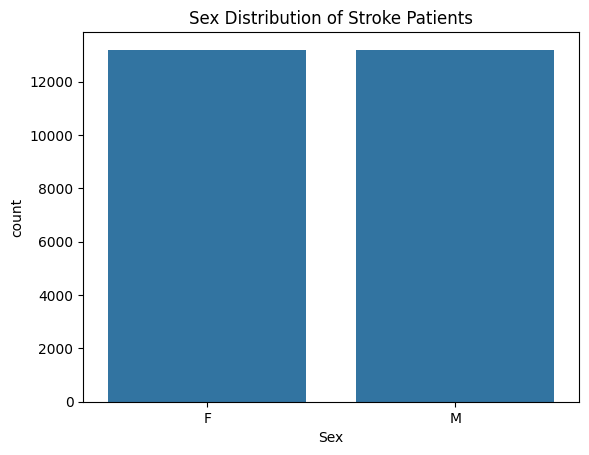

In [70]:
# Gender Distribution
sns.reset_defaults()
plt.rcdefaults()
sns.countplot(x="gender", data=full_df_nn)
plt.xlabel("Sex")
plt.title("Sex Distribution of Stroke Patients")
plt.savefig("sex_distribution.png", dpi=500)
plt.show()

In [88]:
full_df_nn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26381 entries, 0 to 26380
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   subject_id      26381 non-null  int64   
 1   gender          26381 non-null  object  
 2   anchor_age      26381 non-null  int64   
 3   dod             9014 non-null   object  
 4   mortality       26381 non-null  int64   
 5   admittime       26381 non-null  object  
 6   dischtime       26381 non-null  object  
 7   deathtime       3380 non-null   object  
 8   admission_type  26381 non-null  object  
 9   race            26381 non-null  object  
 10  age_group       26381 non-null  category
dtypes: category(1), int64(3), object(7)
memory usage: 2.0+ MB


In [89]:
full_df_nn.describe()

,subject_id,anchor_age,mortality
count,2.638100e+04,26381.000000,26381.000000
mean,1.502240e+07,68.819415,0.341685
std,2.882844e+06,14.803945,0.474284
min,1.000098e+07,18.000000,0.000000
25%,1.252208e+07,60.000000,0.000000
50%,1.503532e+07,70.000000,0.000000
75%,1.752734e+07,80.000000,1.000000
max,1.999999e+07,91.000000,1.000000


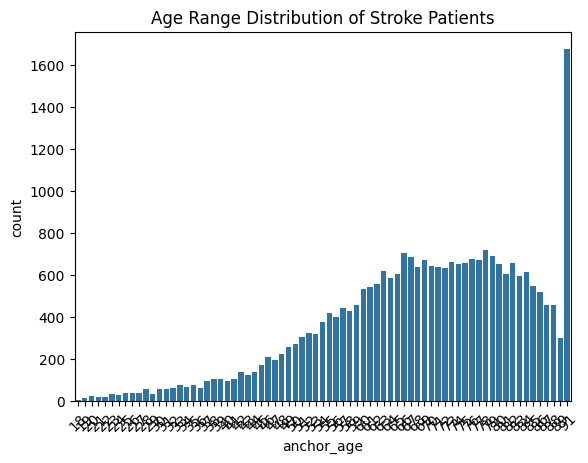

In [90]:
# Age Distribution
sns.countplot(x="anchor_age", data=full_df_nn, order=sorted(full_df_nn["anchor_age"].unique()))
plt.title("Age Range Distribution of Stroke Patients")
plt.xticks(rotation=45)
plt.show()

In [91]:
age_bins= [17, 44, 64, 74, 84, 150]
labels = ["18–44", "45–64", "65–74", "75–84", "85+"]

In [92]:
full_df_nn["age_group"] = pd.cut(full_df_nn["anchor_age"], bins=age_bins, labels=labels, right=True, include_lowest=True)
print(full_df_nn["age_group"].value_counts(dropna=False))
full_df_nn[["anchor_age", "age_group"]].head()

age_group
45–64    7639
75–84    6536
65–74    6527
85+      3954
18–44    1725
Name: count, dtype: int64


,anchor_age,age_group
0,73,65–74
1,89,85+
2,80,75–84
3,68,65–74
4,86,85+


### Changing the class grouping to reflect the age when stroke risk rises (45) from Hayes (2010)

Kelly‐Hayes, M. (2010). Influence of age and health behaviors on stroke risk: lessons from longitudinal studies. Journal of the American Geriatrics Society, 58, S325-S328.

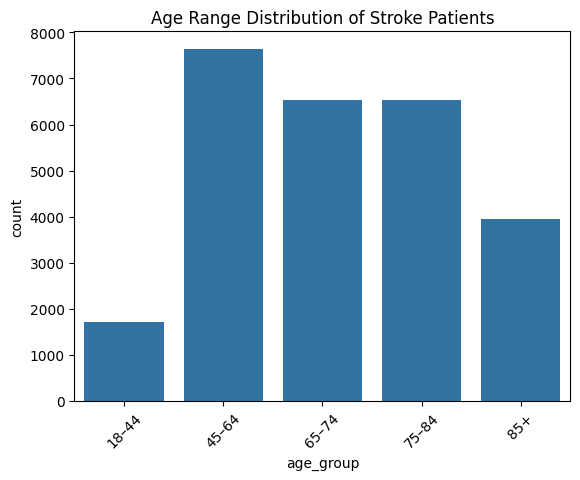

In [93]:
# Age Distribution
age_order = [
    "18–44",
    "45–64",
    "65–74",
    "75–84",
    "85+"
]
sns.countplot(x="age_group", data=full_df_nn, order=age_order)
plt.title("Age Range Distribution of Stroke Patients")
plt.xticks(rotation=45)
plt.savefig("age_distribution.png", dpi=500, bbox_inches='tight')
plt.show()

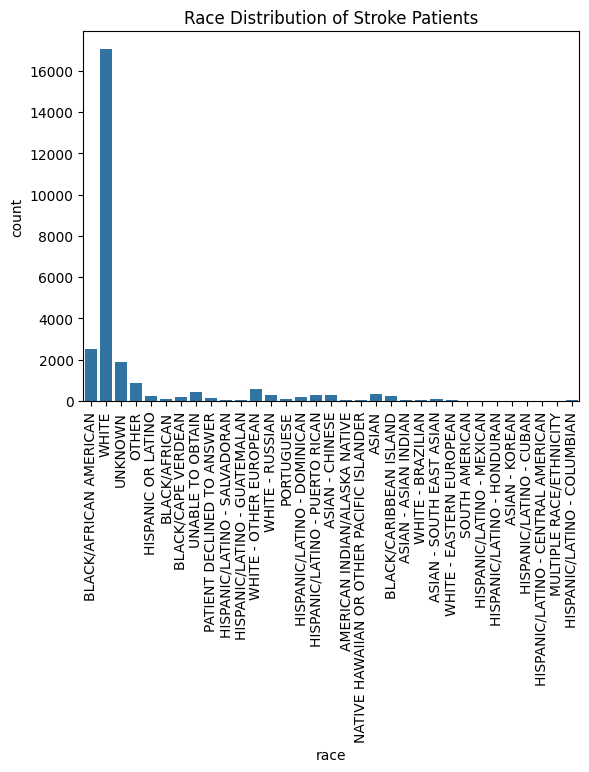

In [94]:
# Race distribution
sns.countplot(x="race", data=full_df_nn)
plt.title("Race Distribution of Stroke Patients")
plt.xticks(rotation=90)
plt.savefig("race_distribution.png", dpi=500, bbox_inches='tight')
plt.show()

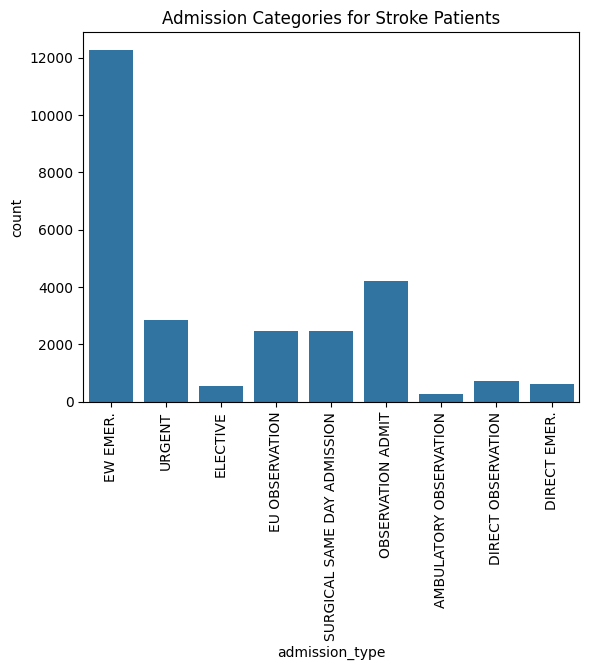

In [95]:
# ICU Category Distribution
sns.countplot(x="admission_type", data=full_df_nn)
plt.title("Admission Categories for Stroke Patients")
plt.xticks(rotation=90)
plt.savefig("admission_distribution.png", dpi=500, bbox_inches='tight')
plt.show()

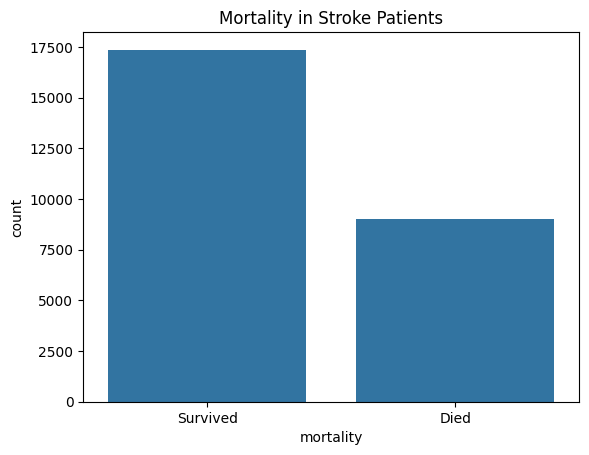

In [96]:
sns.countplot(x="mortality", data=full_df_nn)
plt.title("Mortality in Stroke Patients")
plt.xticks([0,1], ["Survived", "Died"])
plt.savefig("mortality_distribution.png", dpi=500)
plt.show()

In [97]:
mortality_rate = full_df_nn["mortality"].mean() * 100
print(f"60-day mortality rate: {mortality_rate:.2f}%")

60-day mortality rate: 34.17%


In [98]:
mortality_by_gender = full_df_nn.groupby("gender")["mortality"].mean() * 100
print("Mortality by gender (%):")
print(mortality_by_gender)

Mortality by gender (%):
gender
F    33.828433
M    34.508912
Name: mortality, dtype: float64


In [99]:
mortality_by_race = full_df_nn.groupby("race")["mortality"].mean() * 100
print("Mortality by race (%):")
print(mortality_by_race)

Mortality by race (%):
race
AMERICAN INDIAN/ALASKA NATIVE                27.692308
ASIAN                                        34.582133
ASIAN - ASIAN INDIAN                         24.000000
ASIAN - CHINESE                              31.010453
ASIAN - KOREAN                               21.428571
ASIAN - SOUTH EAST ASIAN                     29.885057
BLACK/AFRICAN                                32.258065
BLACK/AFRICAN AMERICAN                       36.685215
BLACK/CAPE VERDEAN                           22.115385
BLACK/CARIBBEAN ISLAND                       26.923077
HISPANIC OR LATINO                           34.901961
HISPANIC/LATINO - CENTRAL AMERICAN           18.181818
HISPANIC/LATINO - COLUMBIAN                  12.500000
HISPANIC/LATINO - CUBAN                      42.857143
HISPANIC/LATINO - DOMINICAN                  18.811881
HISPANIC/LATINO - GUATEMALAN                 28.205128
HISPANIC/LATINO - HONDURAN                   26.666667
HISPANIC/LATINO - MEXICAN            

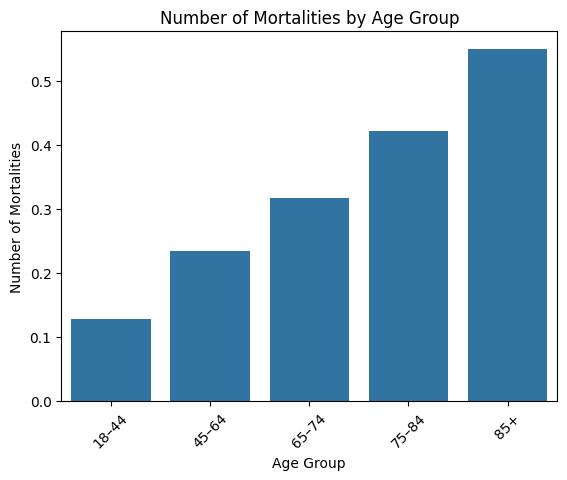

In [100]:
mortality_by_age = full_df_nn.groupby("age_group", observed=False)["mortality"].sum().reset_index()
sns.barplot(x="age_group", y="mortality", data=full_df_nn, order=age_order, errorbar=None)
plt.title("Number of Mortalities by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Mortalities")
plt.xticks(rotation=45)
plt.savefig("mortality_by_age_group.png", dpi=500, bbox_inches='tight')
plt.show()

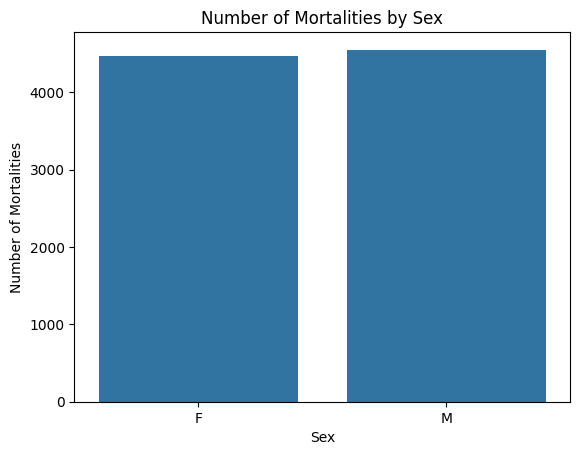

In [101]:
mortality_by_gender = full_df_nn.groupby("gender")["mortality"].sum().reset_index()
sns.barplot(x="gender", y="mortality", data=mortality_by_gender)
plt.title("Number of Mortalities by Sex")
plt.xlabel("Sex")
plt.ylabel("Number of Mortalities")
plt.savefig("mortality_by_sex.png", dpi=500)
plt.show()

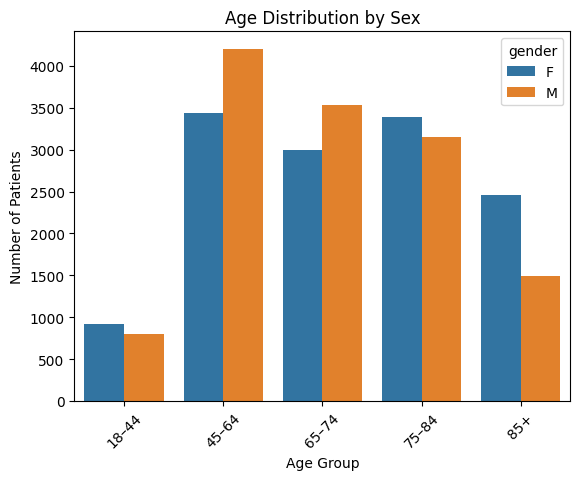

In [102]:
sns.countplot(x="age_group", hue="gender", data=full_df_nn, order=age_order)
plt.title("Age Distribution by Sex")
plt.xlabel("Age Group")
plt.ylabel("Number of Patients")
plt.xticks(rotation=45)
plt.savefig("age_by_sex.png", dpi=500, bbox_inches='tight')
plt.show()

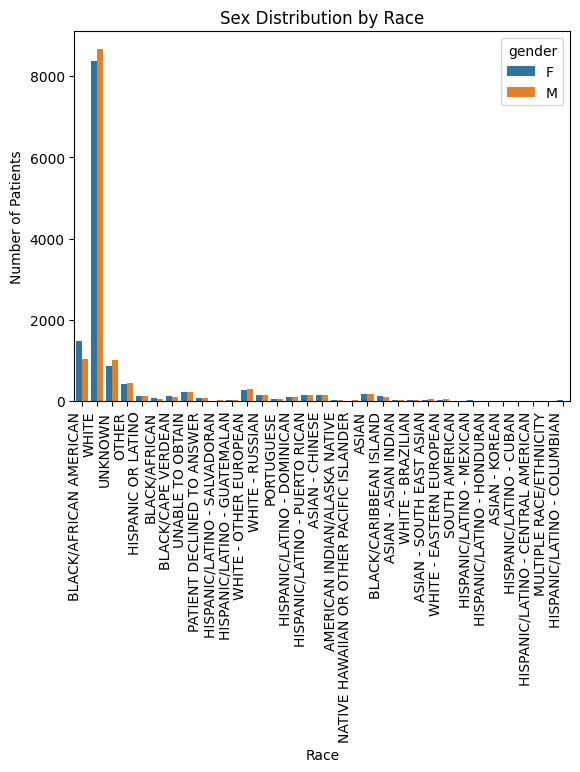

In [103]:
sns.countplot(x="race", hue="gender", data=full_df_nn)
plt.title("Sex Distribution by Race")
plt.xlabel("Race")
plt.ylabel("Number of Patients")
plt.xticks(rotation=90, ha="right")
plt.savefig("sex_by_race.png", dpi=500, bbox_inches="tight")
plt.show()

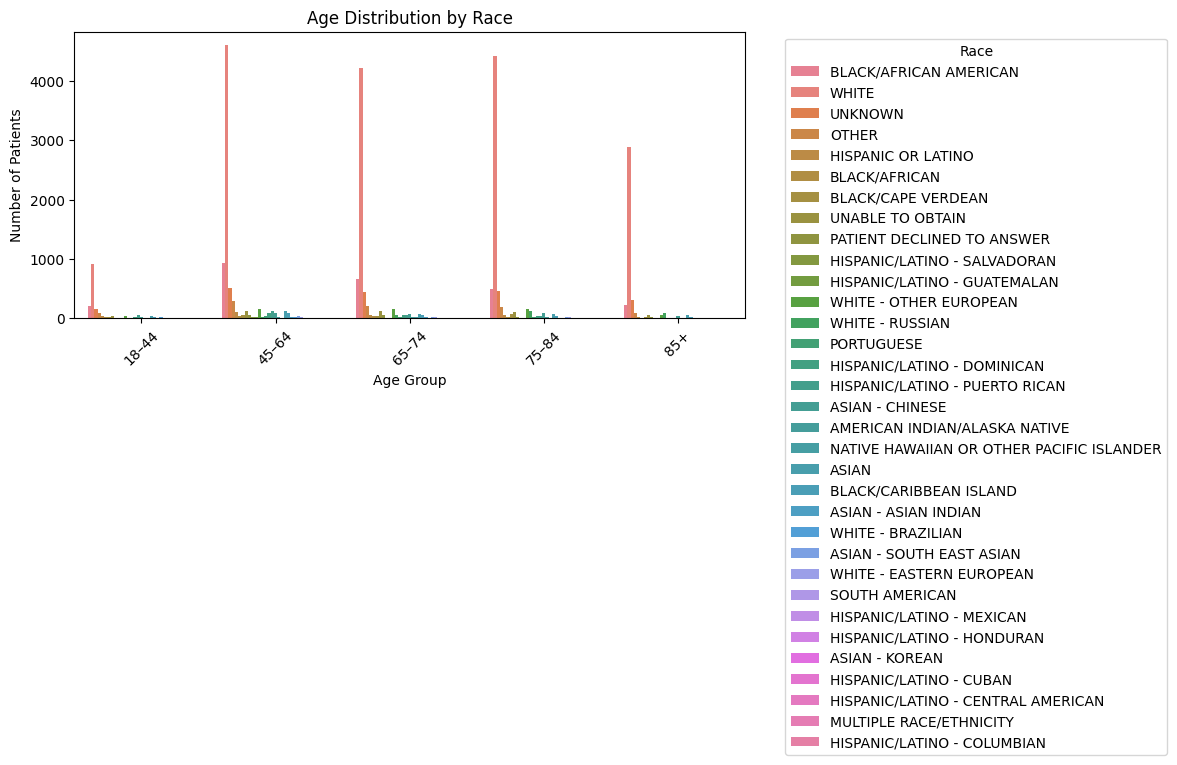

In [104]:
plt.figure(figsize=(12,6))
sns.countplot(x="age_group", hue="race", data=full_df_nn, order=age_order)
plt.title("Age Distribution by Race")
plt.xlabel("Age Group")
plt.ylabel("Number of Patients")
plt.xticks(rotation=45)
plt.legend(title="Race", bbox_to_anchor=(1.05, 1), loc="upper left")  # move legend outside
plt.tight_layout()
plt.savefig("age_by_race.png", dpi=500)
plt.show()